##Estadistica Aplicada

Tercer Examen Parcial

Bryan Alejandro Estrada Rodriguez 1844554

Grupo 42

In [78]:
# librerias Basicas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline

In [ ]:
pip install pmdarima

In [53]:
# Especializadas
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_predict
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
#Tamaño de graficas
plt.rcParams["figure.figsize"]= (10,6)
plt.rcParams["xtick.labelsize"]= 12
plt.rcParams["ytick.labelsize"]= 12
plt.rcParams["axes.labelsize"]= 12

import pmdarima as pm

In [ ]:
metrrey = pd.read_csv("https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/datos_metrorrey.csv")
metrrey.head()

,mes,miles de pasajeros,ingresos (miles de pesos)
0,1995/01,3439.0,3240.0
1,1995/02,2879.0,3623.0
2,1995/03,3103.0,3990.0
3,1995/04,3491.0,3321.0
4,1995/05,3109.0,3777.0


## Estadistica Aplicada

Tercer Parcial

Bryan Alejandro Estrada Rodriguez 1844554

Grupo: 42

In [9]:
# librerias Basicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
# Especializadas
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, plot_predict
from statsmodels.tsa.arima.model import ARIMA


#Tamaño de graficas
plt.rcParams["figure.figsize"]= (10,6)
plt.rcParams["xtick.labelsize"]= 12
plt.rcParams["ytick.labelsize"]= 12
plt.rcParams["axes.labelsize"]= 12

import pmdarima as pm

In [16]:
metrrey = pd.read_csv("https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/datos_metrorrey.csv")
metrrey.head()

,mes,miles de pasajeros,ingresos (miles de pesos)
0,1995/01,3439.0,3240.0
1,1995/02,2879.0,3623.0
2,1995/03,3103.0,3990.0
3,1995/04,3491.0,3321.0
4,1995/05,3109.0,3777.0


1. Muestre de que tipo son las variables del dataframe, revise que no haya missing
values (de haberlos imputar valores). Cersiorarse que exista una variable fecha,
que sea el index y tenga una frecuencia asignada (1.8 puntos)

In [17]:
metrrey.dtypes

mes                           object
miles de pasajeros           float64
ingresos (miles de pesos)    float64
dtype: object

In [18]:
metrrey.isnull().sum()

mes                          0
miles de pasajeros           0
ingresos (miles de pesos)    0
dtype: int64

In [19]:
metrrey["mes"] = pd.to_datetime(metrrey["mes"], format="%Y/%m")
metrrey = metrrey.set_index("mes")
metrrey.head()

,miles de pasajeros,ingresos (miles de pesos)
mes,,
1995-01-01,3439.0,3240.0
1995-02-01,2879.0,3623.0
1995-03-01,3103.0,3990.0
1995-04-01,3491.0,3321.0
1995-05-01,3109.0,3777.0


In [20]:
#Asignacion de frecuencia
metrrey = metrrey.asfreq("MS")
metrrey.index

DatetimeIndex(['1995-01-01', '1995-02-01', '1995-03-01', '1995-04-01',
               '1995-05-01', '1995-06-01', '1995-07-01', '1995-08-01',
               '1995-09-01', '1995-10-01',
               ...
               '2022-11-01', '2022-12-01', '2023-01-01', '2023-02-01',
               '2023-03-01', '2023-04-01', '2023-05-01', '2023-06-01',
               '2023-07-01', '2023-08-01'],
              dtype='datetime64[ns]', name='mes', length=344, freq='MS')

2. Análisis exploratorio. Utilizando código de Python genera un print() para cada una de la siguiente información (8 puntos):

a) Rango de fechas

In [43]:
print(f'El rango de fechas esta entre: {metrrey.index.min().strftime("%Y-%m-%d")} y {metrrey.index.max().strftime("%Y-%m-%d")}')


El rango de fechas esta entre: 1995-01-01 y 2023-08-01


b) Numero de observaciones

In [41]:
print(f'El numero de observaciones es:{ len(metrrey)}')

El numero de observaciones es:344


c) Valor mínimo y valor máximo del número de pasajeros

In [44]:
print(f'El valor minimo de pasajeros es: {metrrey["miles de pasajeros"].min()}. Y el valor maximo de pasajeros es: {metrrey["miles de pasajeros"].max()}')

El valor minimo de pasajeros es: 2397.0 Y el valor maximo de pasajeros es: 17534.523


3. Grafica lo siguiente (8.2 puntos):

a) La serie de miles de pasajeros


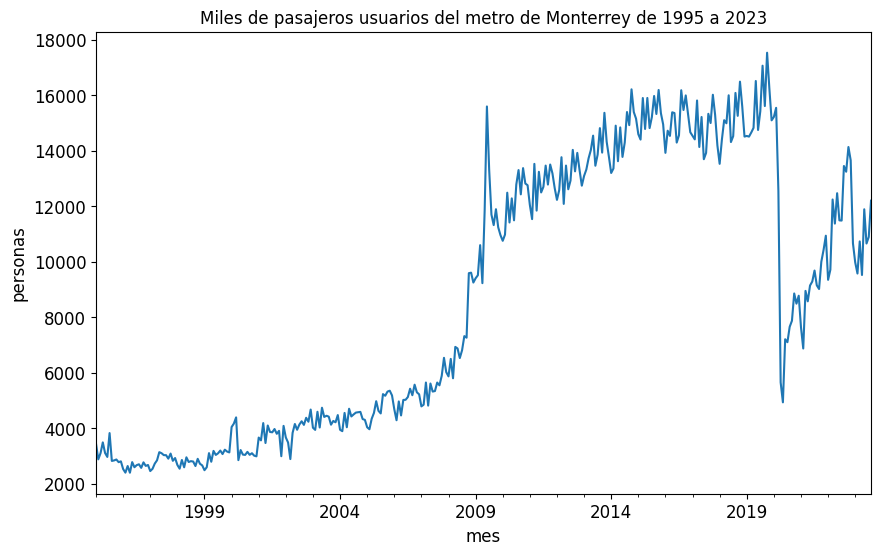

In [34]:
# Graficamos la serie de miles de pasajeros
metrrey["miles de pasajeros"].plot()
plt.title("Miles de pasajeros usuarios del metro de Monterrey de 1995 a 2023")
plt.ylabel("personas");

b) Una media móvil centrada a 7 meses, y explica si la serie tiene tendencia
o no, y si existen ciclos (subidas y caídas) y que se debe cada uno.

In [48]:
metrrey['media_movil'] = metrrey['miles de pasajeros'].rolling(window=7, center=True).mean()

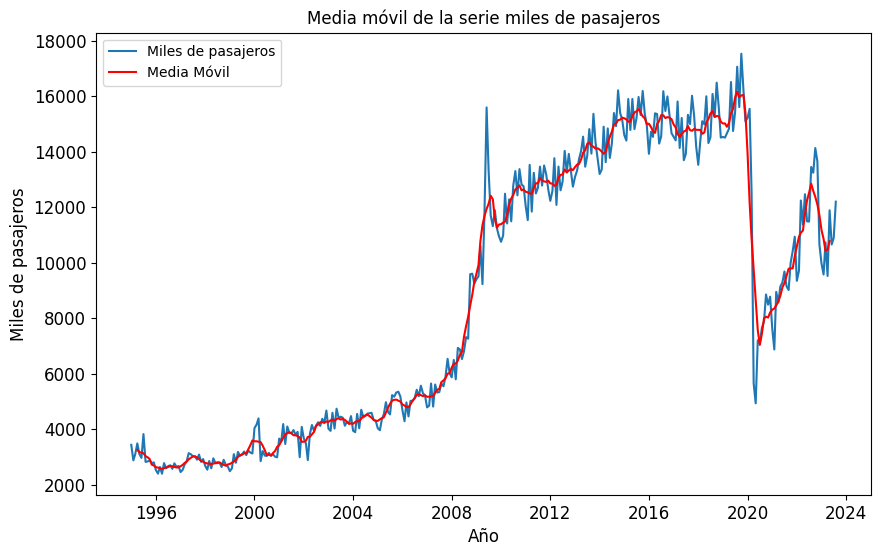

In [49]:
plt.plot(metrrey['miles de pasajeros'], label='Miles de pasajeros')
plt.title('Media móvil de la serie miles de pasajeros')
plt.plot(metrrey['media_movil'], label='Media Móvil', color='red')
plt.ylabel('Miles de pasajeros')
plt.xlabel('Año')
plt.legend();

No tiene una tendencia clara, pero si existen ciclos claros de subida y bajada. Se muestran subidas y caidas entre los 2008 y 2010 que esto podria ser por la crisis economica del 2008. Por otra parte tambien se muestra otra gran caida entre el 2019-2020 y esto ya puede ser mas claro por la pandemia de COVID-19.


4. El director de Metrorrey planea hacer mantenimiento a las estaciones y los vagones, pero no sabe la fecha adecuada para hacerlo. Utiliza el modelo ETS para obtener el componente estacional de la serie y señala el mes o meses adecuados para dar mantenimiento (8.2 puntos).

In [54]:
ets = seasonal_decompose(metrrey['miles de pasajeros'],model='mult')

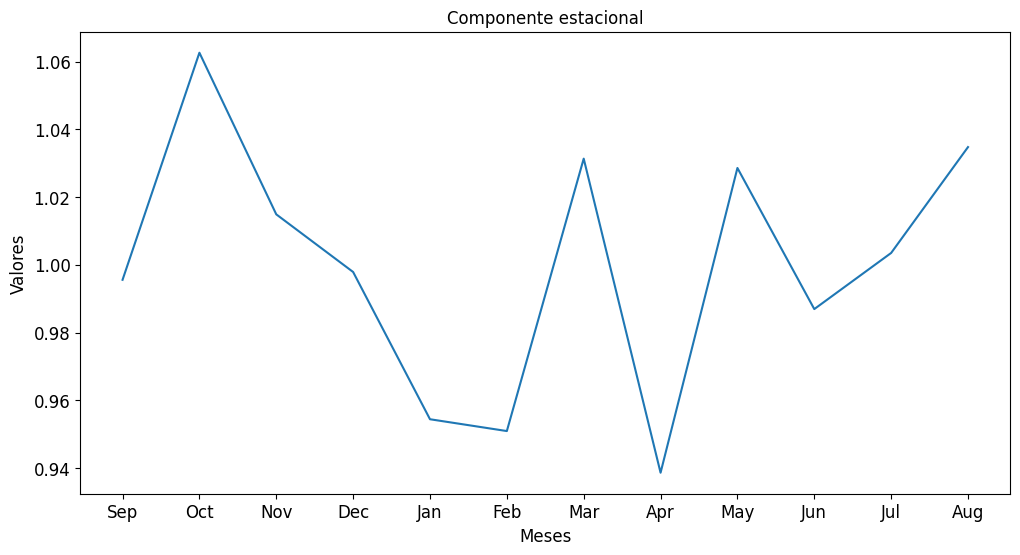

In [76]:
## Componente estacional
ini = '2022-09-01'
fin = '2023-08-01'
estacional = ets.seasonal[ini:fin]
meses = estacional.index.strftime('%b')

plt.figure(figsize=(12, 6))
plt.plot(meses, estacional)
plt.title('Componente estacional')
plt.xlabel('Meses')
plt.ylabel('Valores')
plt.show()

Los meses que mejor se prestan para poder hacerle mantenimiento a los bagones el metro son entre los meses DICIEMBRE-FEBRERO y de mediados de MARZO a mediados de ABRIL


5. El director de Metrorrey quiere saber los ingresos por pasaje y el número de pasajeros los siguientes 5 meses. Utiliza el método de Holt-Winters para pronosticar el número de pasajeros los próximos 5 meses, cada pronóstico multiplícalo por $7.1 para tener un estimado de los ingresos (8.2 puntos).

In [79]:
modelo = sm.tsa.ExponentialSmoothing(metrrey['miles de pasajeros'], seasonal='add', seasonal_periods=12)
modelo_fit = modelo.fit()

In [84]:
metrrey_pronostico = modelo_fit.forecast(steps=5)
ingreso = metrrey_pronostico * 7.1

In [85]:
print("El pronóstico de pasajeros para los próximos 5 meses es de:\n", metrrey_pronostico)
print("El ingreso estimado de los próximos 5 meses es de:\n", ingreso)

El pronóstico de pasajeros para los próximos 5 meses es de:
 2023-09-01    11532.223045
2023-10-01    12305.606260
2023-11-01    11607.822970
2023-12-01    11098.028687
2024-01-01    10895.852264
Freq: MS, dtype: float64
El ingreso estimado de los próximos 5 meses es de:
 2023-09-01    81878.783622
2023-10-01    87369.804446
2023-11-01    82415.543087
2023-12-01    78796.003681
2024-01-01    77360.551077
Freq: MS, dtype: float64


6. Realiza un pronóstico de los miles de pasajeros con el modelo ARIMA
cumpliendo los siguientes pasos:

a) Realiza una prueba de raíz unitaria a la serie original (8.2 puntos)

H0: No es una serie estacionaria

H1: Es una serie estacionaria

In [87]:
prue_adf = adfuller(metrrey['miles de pasajeros'])
pvalue = prue_adf[1]
pvalue.round(2)

0.58

Rechazamos H0 si pvalor <= Alfa

pvalue = 0.58 <= 0.05 = Alfa

No rechazamos H0, el indicador mensual de consumo no es una serie estacionaria

b) En caso de que no sea estacionaria aplica primeras diferencias, y realiza la prueba de raíz unitaria para verificar que la serie sea estacionaria (8.2 puntos)


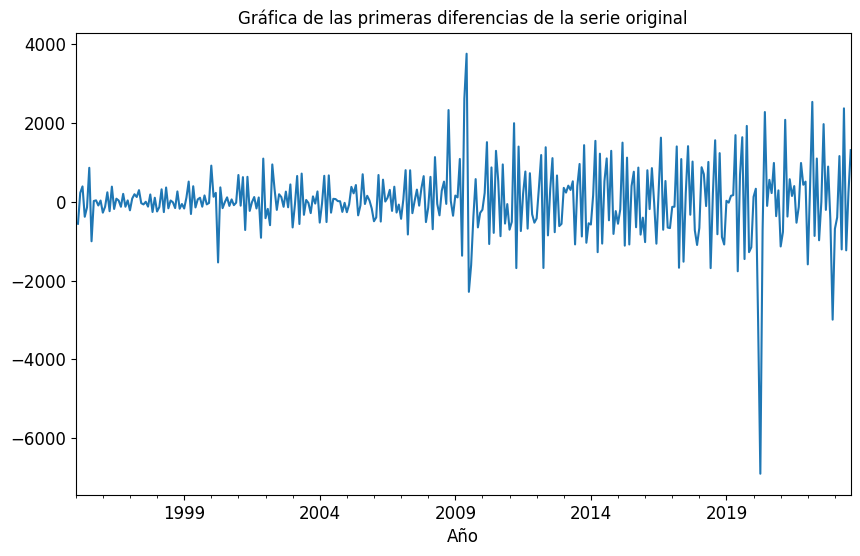

In [89]:
metrrey['miles de pasajeros.diff'] = metrrey['miles de pasajeros'].diff()
plt.title('Gráfica de las primeras diferencias de la serie original')
metrrey['miles de pasajeros.diff'].plot()
plt.xlabel('Año')
plt.show()

In [90]:
prueba_adf = adfuller(metrrey['miles de pasajeros.diff'].dropna())
pvalue1 = prueba_adf[1]
pvalue1.round(2)

0.0

0.0 <= 0.05

Rechazamos H0, significa que las primeras diferencias de los miles de pasajeros son una serie estacionaria

Miles de pasajeros integrada I(1) = ARIMA (p,q,q)

1ras diferencias de miles de pasajeros I(0) = ARIMA (p,0,q)

d) Realiza las graficas de autocorrelación de la serie estacionaria para verificar si la serie tiene o no un componente estacional (8.2 puntos)

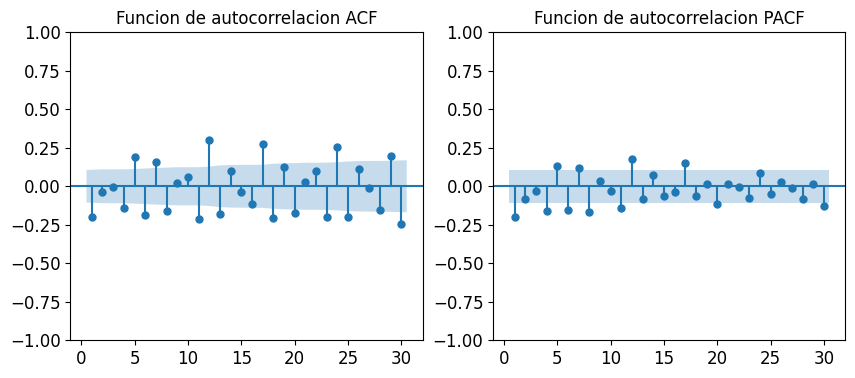

In [91]:
# grafica de correlacion
ig, ax = plt.subplots(1,2,figsize=(10,4))
#graf1
plot_acf(metrrey['miles de pasajeros.diff'].dropna(),zero=False,lags=30,ax=ax[0],title='Funcion de autocorrelacion ACF' )

#graf2
plot_pacf(metrrey['miles de pasajeros.diff'].dropna(),zero=False,lags=30,ax=ax[1],title='Funcion de autocorrelacion PACF')
plt.show()

Tiene un componente estacional porque los meses estan o tienen una fuerte correlacion

e) Utiliza auto_arima para encontrar el orden del modelo arima, dando el parámetro information_criterion prueba y muestra el resultado, con aic, bic, hqic, oob, en caso de que resulten diferente elegir aic si tu matricula termina en par, sino termina en par elegir uno distinto a aic. (8.2 puntos)

In [98]:
pm.auto_arima(metrrey['miles de pasajeros'],
              ##ARIMA normal
              start_p=1,
              start_q=1,
              m=5,
              max_p=7,
              max_q=7,
              ic='aic',
              ## Estacional
              seasonal= True,
              start_P=1,
              start_Q=1,
              max_P=12,
              max_Q=12)

ARIMA(order=(0, 1, 2), scoring_args={}, seasonal_order=(2, 0, 2, 5),
      suppress_warnings=True, with_intercept=False)

In [99]:
pm.auto_arima(metrrey['miles de pasajeros'],
              ## ARIMA normal
              start_p=1,
              start_q=1,
              m=5,
              max_p=7,
              max_q=7,
              ic='bic',
              ## Estacional
              seasonal= True,
              start_P=1,
              start_Q=1,
              max_P=12,
              max_Q=12)

ARIMA(order=(0, 1, 2), scoring_args={}, seasonal_order=(2, 0, 2, 5),
      suppress_warnings=True, with_intercept=False)

In [100]:
pm.auto_arima(metrrey['miles de pasajeros'],
              ## ARIMA noraml
              start_p=1,
              start_q=1,
              m=5,
              max_p=7,
              max_q=7,
              ic='hqic',
              ## Parte estacional
              seasonal= True,
              #Orden estacional
              start_P=1,
              start_Q=1,
              max_P=12,
              max_Q=12)

ARIMA(order=(0, 1, 2), scoring_args={}, seasonal_order=(2, 0, 2, 5),
      suppress_warnings=True, with_intercept=False)

In [101]:
pm.auto_arima(metrrey['miles de pasajeros'],
              ## ARIMA normal
              start_p=1,
              start_q=1,
              m=5,
              max_p=7,
              max_q=7,
              ic='oob',
              ## Estacional
              seasonal= True,
              start_P=1,
              start_Q=1,
              max_P=12,
              max_Q=12)

ARIMA(order=(0, 1, 2), scoring_args={}, seasonal_order=(2, 0, 2, 5),
      suppress_warnings=True, with_intercept=False)

Mi matricula es par, por lo que tomare el AIC

f) Con el orden del modelo arima obtenido estima el modelo arima (8.2 puntos)


In [102]:
## Estimar el modelo
model = ARIMA(metrrey['miles de pasajeros'], order=(0,1,2), seasonal_order=(2,0,2,5))
results = model.fit()
print(results.summary())

                                    SARIMAX Results                                    
Dep. Variable:              miles de pasajeros   No. Observations:                  344
Model:             ARIMA(0, 1, 2)x(2, 0, 2, 5)   Log Likelihood               -2783.403
Date:                         Sun, 05 Nov 2023   AIC                           5580.807
Time:                                 02:54:04   BIC                           5607.671
Sample:                             01-01-1995   HQIC                          5591.508
                                  - 08-01-2023                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0243      0.034     -0.708      0.479      -0.091       0.043
ma.L2         -0.2060      0.044     -4.685      0.000     

/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


g) Realiza la gráfica del pronóstico a 5 meses con los intervalos de confianza y la serie original desde 2021 (8.2 puntos)


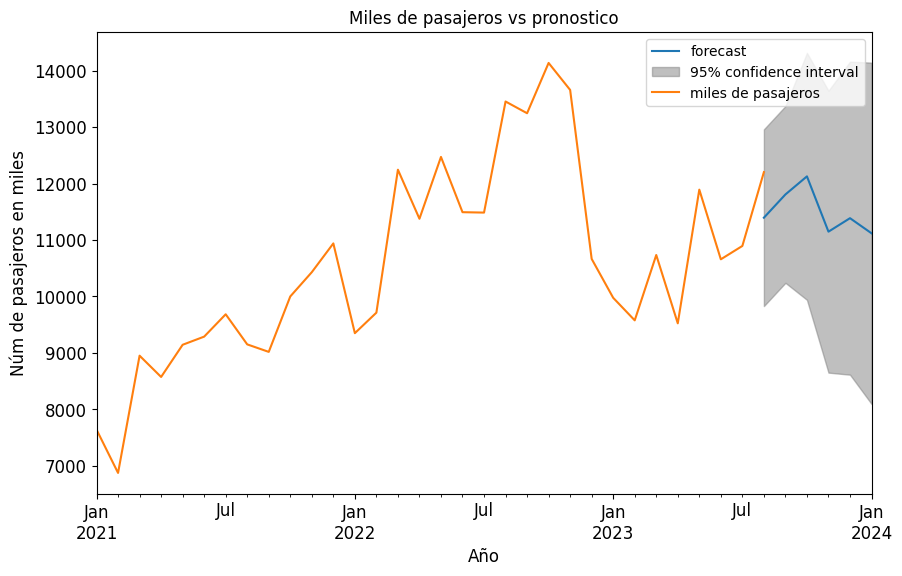

In [103]:
serie_original = metrrey['2021-01-01':]
plot_predict(results, '2023-08-01', '2024-01-01')
serie_original['miles de pasajeros'].plot(figsize=(10,6));
plt.title('Miles de pasajeros vs pronostico')
plt.xlabel('Año')
plt.ylabel('Núm de pasajeros en miles')
plt.legend()
plt.show()

h) Realiza el pronostico a 5 meses con los intervalos de confianza (8.2 puntos)


In [104]:
forecast = results.get_forecast(steps=5)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [105]:
inicio = '2023-09-01'
final = '2024-01-01'

In [106]:
pronostico_valor = forecast_mean[inicio:final]
pronostico_intervalos = forecast_ci.loc[inicio:final]

In [107]:
pronostico = pd. DataFrame({
    'pronóstico': pronostico_valor,
    'limite inferior': pronostico_intervalos.iloc[:,0],
    'limite superior': pronostico_intervalos.iloc[:,1]
})

In [108]:
pronostico

,pronóstico,limite inferior,limite superior
2023-09-01,11806.438444,10241.400418,13371.476469
2023-10-01,12126.606575,9939.991450,14313.221700
2023-11-01,11147.322819,8650.823545,13643.822094
2023-12-01,11386.253198,8614.298733,14158.207662
2024-01-01,11118.616121,8096.207372,14141.024871


i) Calcula los ingresos y el intervalo de los ingreso multiplicando por $7.1 (8.2 puntos)

In [110]:
pasaje = 7.1

ingresos = pronostico * pasaje
print("Ingresos e intervalo estimados para los próximos 5 meses:  \n", ingresos)



Ingresos e intervalo estimados para los próximos 5 meses:  
               pronóstico  limite inferior  limite superior
2023-09-01  83825.712952     72713.942971     94937.482933
2023-10-01  86098.906683     70573.939298    101623.874069
2023-11-01  79145.992017     61420.847167     96871.136867
2023-12-01  80842.397705     61161.521008    100523.274403
2024-01-01  78942.174462     57483.072338    100401.276587
